# Airline Tweet Sentiment with Multinomial Naive Bayes
This notebook keeps only positive and negative tweets from the Twitter US Airline Sentiment dataset, cleans them (links, @mentions and `#` removed, negations kept), vectorizes them with Bag-of-Words counts fitted on the training split only, and trains a Multinomial Naive Bayes classifier. On the test split it reaches 90.6% accuracy but only 0.611 recall (F1 0.726) for the positive class, because word independence ignores negation and sarcasm.

In [1]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
RANDOM_STATE = 42   # fixed so every number in this notebook is reproducible

import glob, os
def find_file(name):
    """Locate a data file in the current folder, Colab (/content) or Kaggle (/kaggle/input)."""
    for root in ['.', '/content', '/kaggle/input']:
        hits = glob.glob(os.path.join(root, '**', name), recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f"{name} not found - upload it to your Colab session first.")


In [2]:
def get_metrics(y_true, y_pred):
    return {'Accuracy': accuracy_score(y_true, y_pred), 'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred), 'F1-score': f1_score(y_true, y_pred)}


## 1. Load and explore

In [3]:
# Task 1 (continued) - load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_raw = pd.read_csv(find_file('Tweets.csv'))
print("Twitter US Airline Sentiment (raw)")
print("Rows:", tweets_raw.shape[0], "| Columns:", tweets_raw.shape[1])

raw_balance = pd.DataFrame({'count': tweets_raw['airline_sentiment'].value_counts(),
                            'percent': (tweets_raw['airline_sentiment'].value_counts(normalize=True) * 100).round(2)})
print("\nClass balance BEFORE dropping neutral:")
display(raw_balance)

# keep only positive / negative tweets, and only the two columns we need
tweets = tweets_raw.loc[tweets_raw['airline_sentiment'] != 'neutral', ['airline_sentiment', 'text']].copy()
print("Rows left after dropping neutral:", tweets.shape[0], f"(dropped {len(tweets_raw) - len(tweets)})")
print("Missing values:", int(tweets.isna().sum().sum()))
display(tweets.head())

tweet_balance = pd.DataFrame({'count': tweets['airline_sentiment'].value_counts(),
                              'percent': (tweets['airline_sentiment'].value_counts(normalize=True) * 100).round(2)})
print("Class balance AFTER dropping neutral:")
display(tweet_balance)


Twitter US Airline Sentiment (raw)
Rows: 14640 | Columns: 15

Class balance BEFORE dropping neutral:


,count,percent
airline_sentiment,,
negative,9178,62.69
neutral,3099,21.17
positive,2363,16.14


Rows left after dropping neutral: 11541 (dropped 3099)
Missing values: 0


,airline_sentiment,text
1,positive,@VirginAmerica plus you've added commercials to the experience... tacky.
3,negative,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &..."
4,negative,@VirginAmerica and it's a really big bad thing about it
5,negative,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's r...
6,positive,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)"


Class balance AFTER dropping neutral:


,count,percent
airline_sentiment,,
negative,9178,79.53
positive,2363,20.47


## 2. Cleaning & vectorization

In [4]:
# Task 11 - clean and vectorize the sentiment data (our own approach)
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove links
    text = re.sub(r'@\w+', ' ', text)                 # remove @mentions (airline handles / usernames)
    text = text.replace('&amp;', ' and ')             # HTML entity left in the raw text
    text = text.replace('#', ' ')                     # keep hashtag WORD, drop the '#'
    text = re.sub(r'[^a-z\s]', ' ', text)             # drop punctuation, digits, emojis
    return re.sub(r'\s+', ' ', text).strip()
# NOTE: stop words are deliberately NOT removed, so negations such as "not" / "no" / "never" survive.

tweets['clean'] = tweets['text'].apply(clean_tweet)
tweets['y'] = (tweets['airline_sentiment'] == 'positive').astype(int)   # positive = 1, negative = 0
display(tweets[['text', 'clean']].head(5))

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    tweets['clean'], tweets['y'], test_size=0.2, random_state=RANDOM_STATE, stratify=tweets['y'])

vec_b = CountVectorizer()
Xb_train_vec = vec_b.fit_transform(Xb_train)   # fit on training tweets only
Xb_test_vec = vec_b.transform(Xb_test)

print("Train / test tweets:", len(Xb_train), "/", len(Xb_test))
print("Positive share  train: %.2f%%  test: %.2f%%" % (yb_train.mean() * 100, yb_test.mean() * 100))
print("Vocabulary size (number of features):", len(vec_b.get_feature_names_out()))
print("Train matrix shape:", Xb_train_vec.shape, "| Test matrix shape:", Xb_test_vec.shape)


,text,clean
1,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you ve added commercials to the experience tacky
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",it s really aggressive to blast obnoxious entertainment in your guests faces and they have littl...
4,@VirginAmerica and it's a really big bad thing about it,and it s a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's r...,seriously would pay a flight for seats that didn t have this playing it s really the only bad th...
6,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",yes nearly every time i fly vx this ear worm won t go away


Train / test tweets: 9232 / 2309
Positive share  train: 20.47%  test: 20.49%
Vocabulary size (number of features): 8746
Train matrix shape: (9232, 8746) | Test matrix shape: (2309, 8746)


## 3. Naive Bayes model & evaluation

,Naive Bayes (sentiment)
Accuracy,0.9056
Precision,0.8947
Recall,0.6110
F1-score,0.7261


TN=1802 (negative kept)  FP=34 (negative called positive)  FN=184 (positive missed)  TP=289 (positive caught)


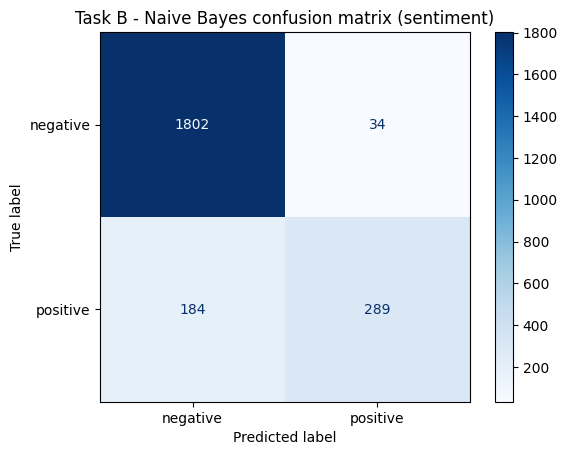

In [5]:
# Task 13 - train MultinomialNB, compute metrics, plot confusion matrix
nb_b = MultinomialNB()
nb_b.fit(Xb_train_vec, yb_train)
pred_b = nb_b.predict(Xb_test_vec)

metrics_nb_b = get_metrics(yb_test, pred_b)
display(pd.DataFrame(metrics_nb_b, index=['Naive Bayes (sentiment)']).T.round(4))

cm_b = confusion_matrix(yb_test, pred_b)
tn, fp, fn, tp = cm_b.ravel()
print(f"TN={tn} (negative kept)  FP={fp} (negative called positive)  FN={fn} (positive missed)  TP={tp} (positive caught)")

ConfusionMatrixDisplay(cm_b, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Task B - Naive Bayes confusion matrix (sentiment)')
plt.show()


In [6]:
# Supporting evidence for Answer 14 - baseline, most informative words, and negation / sarcasm probes
majority_acc = 1 - yb_test.mean()
print("Accuracy of always predicting 'negative' (majority baseline): %.4f" % majority_acc)

vocab_b = vec_b.get_feature_names_out()
ratio_b = nb_b.feature_log_prob_[1] - nb_b.feature_log_prob_[0]
print("Most POSITIVE words:", list(vocab_b[np.argsort(ratio_b)[::-1][:10]]))
print("Most NEGATIVE words:", list(vocab_b[np.argsort(ratio_b)[:10]]))

probes = [
    "the flight was not bad at all",
    "never had such a great flight",
    "not good",
    "thanks for losing my bag, great job",
    "thanks for the wonderful flight",
]
rows = []
for msg in probes:
    p_pos = nb_b.predict_proba(vec_b.transform([clean_tweet(msg)]))[0, 1]
    rows.append({'text': msg, 'prediction': 'positive' if p_pos >= 0.5 else 'negative', 'P(positive)': round(p_pos, 3)})
display(pd.DataFrame(rows))


Accuracy of always predicting 'negative' (majority baseline): 0.7951
Most POSITIVE words: ['kudos', 'smooth', 'passbook', 'comfortable', 'fantastic', 'favorite', 'aww', 'lauren', 'admiral', 'rock']
Most NEGATIVE words: ['worst', 'rude', 'terrible', 'disappointed', 'ridiculous', 'hrs', 'hours', 'fail', 'money', 'hold']


,text,prediction,P(positive)
0,the flight was not bad at all,negative,0.013
1,never had such a great flight,negative,0.277
2,not good,negative,0.167
3,"thanks for losing my bag, great job",positive,0.908
4,thanks for the wonderful flight,positive,0.962
